# Задание

Используя шаблон ноутбука для распознавания видов одежды и аксессуаров из набора **fashion_mnist**, выполните следующие действия:

1. Создайте **9** моделей нейронной сети с различными архитектурами и сравните в них значения точности на проверочной выборке (на последней эпохе) и на тестовой выборке.  Используйте следующее деление: обучающая выборка - **50000** примеров, проверочная выборка - **10000** примеров, тестовая выборка - **10000** примеров.

2. Создайте сравнительную таблицу в конце ноутбука, напишите свои выводы по результатам проведенных тестов.

## Импорт библиотек и подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.datasets import fashion_mnist

# Загрузка данных
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# Разделение
x_train, x_val = x_train_full[:50000], x_train_full[50000:]
y_train, y_val = y_train_full[:50000], y_train_full[50000:]

# Нормализация
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (50000, 28, 28)
Validation: (10000, 28, 28)
Test: (10000, 28, 28)


## Описание базы

### База: одежда, обувь и аксессуары
- Датасет состоит из набора изображений одежды, обуви, аксессуаров и их классов.
- Изображения одного вида хранятся в numpy-массиве **(28, 28)** - **x_train, x_test**.
- База содержит **10** классов: (Футболка, Брюки, Пуловер, Платье, Пальто, Сандалии/Босоножки, Рубашка, Кроссовки, Сумочка, Ботильоны) - **y_train, y_test**.
- Примеров: train - **60000**, test - **10000**.

## Визуализация

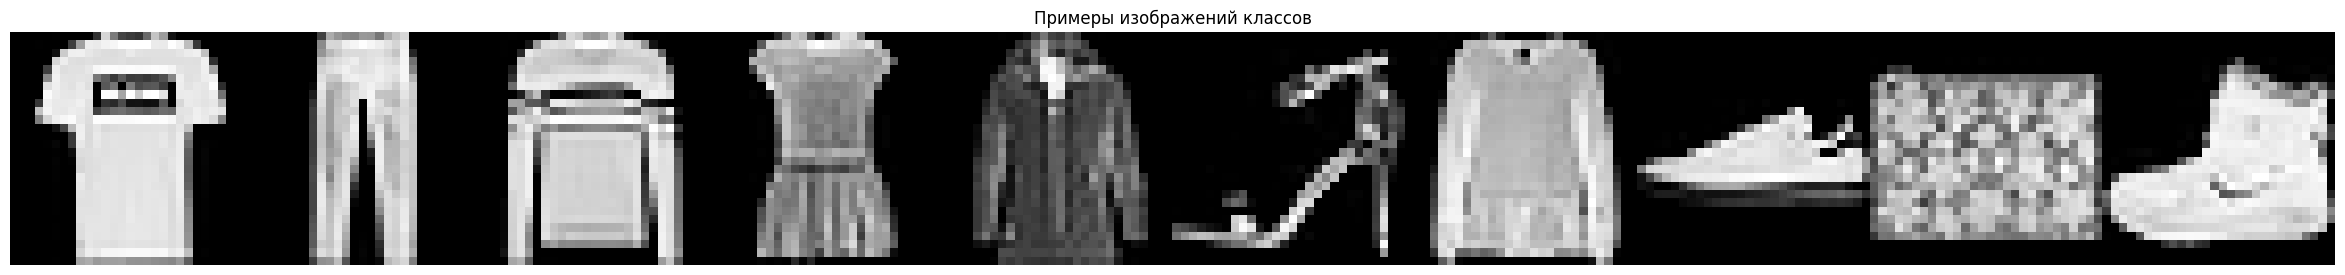

In [2]:
imgs = np.array([x_train[y_train==i][0] for i in range(10)])
imgs = np.concatenate(imgs, axis=1)

plt.figure(figsize=(30,6))
plt.imshow(imgs, cmap='Greys_r')
plt.title("Примеры изображений классов")
plt.axis('off')
plt.show()

## Модель 1 - Базовая полносвязная нейронная сеть (Dense)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8009 - loss: 0.5790 - val_accuracy: 0.8381 - val_loss: 0.4689
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8535 - loss: 0.4205 - val_accuracy: 0.8603 - val_loss: 0.3936
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8673 - loss: 0.3758 - val_accuracy: 0.8630 - val_loss: 0.3945
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8746 - loss: 0.3475 - val_accuracy: 0.8652 - val_loss: 0.3762
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8816 - loss: 0.3310 - val_accuracy: 0.8722 - val_loss: 0.3496
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8875 - loss: 0.3102 - val_accuracy: 0.8765 - val_loss: 0.3486
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8907 - loss: 0.2983 - val_accuracy: 0.8793 - val_loss: 0.3383
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8951 - loss: 0.2864 - val_accuracy: 0.

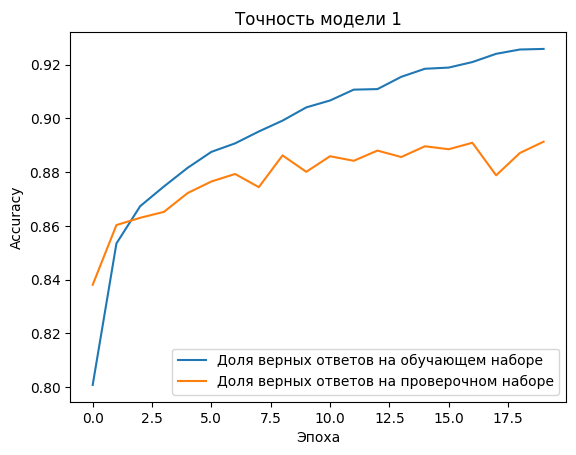

In [3]:
model1 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model1.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history1 = model1.fit(x_train, y_train, epochs=20, batch_size=128,
                      validation_data=(x_val, y_val))

scores1 = model1.evaluate(x_test, y_test, verbose=0)

print("Val:", history1.history['val_accuracy'][-1])
print("Test:", scores1[1])

plt.plot(history1.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history1.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 1")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 2 - Полносвязная сеть с регуляризацией Dropout

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7712 - loss: 0.6524 - val_accuracy: 0.8435 - val_loss: 0.4424
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8397 - loss: 0.4432 - val_accuracy: 0.8553 - val_loss: 0.3919
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8552 - loss: 0.3987 - val_accuracy: 0.8657 - val_loss: 0.3710
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8614 - loss: 0.3801 - val_accuracy: 0.8685 - val_loss: 0.3616
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8707 - loss: 0.3583 - val_accuracy: 0.8707 - val_loss: 0.3547
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8753 - loss: 0.3466 - val_accuracy: 0.8720 - val_loss: 0.3567
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8751 - loss: 0.3387 - val_accuracy: 0.8757 - val_loss: 0.3401
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8794 - loss: 0.3302 - val_accuracy: 0

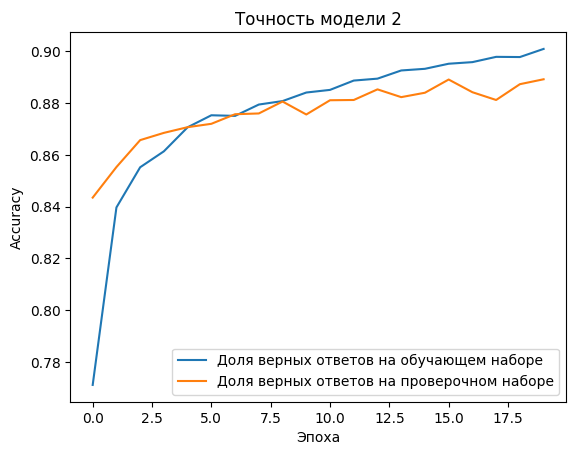

In [4]:
model2 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model2.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history2 = model2.fit(x_train, y_train, epochs=20, batch_size=128,
                      validation_data=(x_val, y_val))

scores2 = model2.evaluate(x_test, y_test, verbose=0)

print("Val:", history2.history['val_accuracy'][-1])
print("Test:", scores2[1])

plt.plot(history2.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history2.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 2")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 3 - Полносвязная сеть с Batch Normalization и Dropout

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8152 - loss: 0.5171 - val_accuracy: 0.8341 - val_loss: 0.4541
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8548 - loss: 0.4002 - val_accuracy: 0.8512 - val_loss: 0.3954
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8659 - loss: 0.3697 - val_accuracy: 0.8445 - val_loss: 0.4373
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8707 - loss: 0.3517 - val_accuracy: 0.8670 - val_loss: 0.3611
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8744 - loss: 0.3414 - val_accuracy: 0.8572 - val_loss: 0.3991
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8787 - loss: 0.3309 - val_accuracy: 0.8745 - val_loss: 0.3469
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8806 - loss: 0.3203 - val_accuracy: 0.8618 - val_loss: 0.3847
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8856 - loss: 0.3103 - val_accuracy: 0

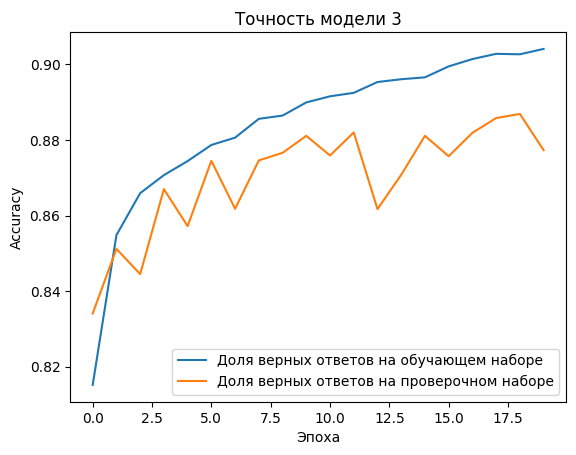

In [5]:
model3 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model3.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history3 = model3.fit(x_train, y_train, epochs=20, batch_size=128,
                      validation_data=(x_val, y_val))

scores3 = model3.evaluate(x_test, y_test, verbose=0)

plt.plot(history3.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history3.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 3")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 4 - Углубленная полносвязная нейронная сеть

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8399 - loss: 0.4443 - val_accuracy: 0.8466 - val_loss: 0.4200
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8724 - loss: 0.3446 - val_accuracy: 0.8148 - val_loss: 0.4990
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8837 - loss: 0.3153 - val_accuracy: 0.8560 - val_loss: 0.3886
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8923 - loss: 0.2916 - val_accuracy: 0.8626 - val_loss: 0.3863
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8969 - loss: 0.2749 - val_accuracy: 0.8565 - val_loss: 0.4092
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9029 - loss: 0.2626 - val_accuracy: 0.8555 - val_loss: 0.4025
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9050 - loss: 0.2529 - val_accuracy: 0.8642 - val_loss: 0.4018
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9094 - loss: 0.2415 - val_accuracy: 0

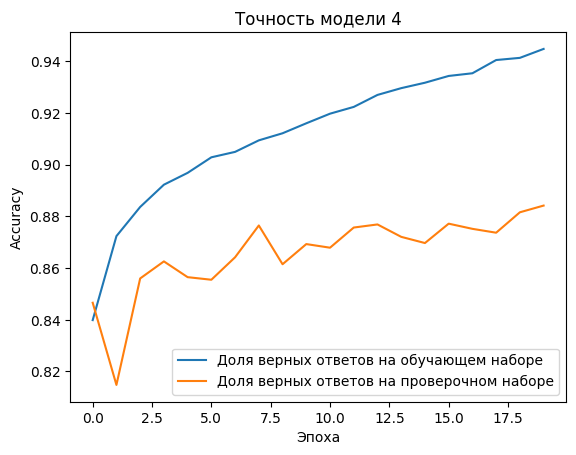

In [6]:
model4 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model4.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history4 = model4.fit(x_train, y_train, epochs=20, batch_size=128,
                      validation_data=(x_val, y_val))

scores4 = model4.evaluate(x_test, y_test, verbose=0)

plt.plot(history4.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history4.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 4")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 5 - Базовая сверточная нейронная сеть (CNN)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8353 - loss: 0.4711 - val_accuracy: 0.8774 - val_loss: 0.3471
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8888 - loss: 0.3151 - val_accuracy: 0.8948 - val_loss: 0.2948
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9046 - loss: 0.2667 - val_accuracy: 0.9050 - val_loss: 0.2673
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9162 - loss: 0.2341 - val_accuracy: 0.9051 - val_loss: 0.2561
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9238 - loss: 0.2122 - val_accuracy: 0.9109 - val_loss: 0.2478
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9303 - loss: 0.1941 - val_accuracy: 0.9127 - val_loss: 0.2401
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9357 - loss: 0.1753 - val_accuracy: 0.9095 - val_loss: 0.2494
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9399 - loss: 0.1611 - val_accuracy: 0.

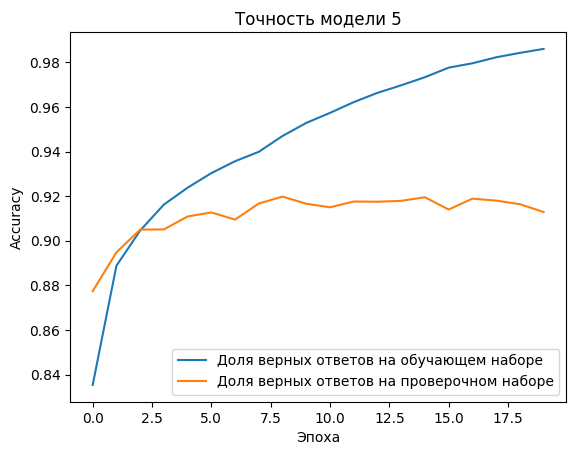

In [7]:
model5 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model5.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history5 = model5.fit(x_train.reshape(-1,28,28,1), y_train,
                      epochs=20, batch_size=128,
                      validation_data=(x_val.reshape(-1,28,28,1), y_val))

scores5 = model5.evaluate(x_test.reshape(-1,28,28,1), y_test, verbose=0)

plt.plot(history5.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history5.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 5")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 6 - Сверточная сеть с регуляризацией Dropout

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7750 - loss: 0.6206 - val_accuracy: 0.8413 - val_loss: 0.4298
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8567 - loss: 0.3966 - val_accuracy: 0.8686 - val_loss: 0.3692
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8748 - loss: 0.3440 - val_accuracy: 0.8814 - val_loss: 0.3252
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8854 - loss: 0.3152 - val_accuracy: 0.8846 - val_loss: 0.3168
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8925 - loss: 0.2931 - val_accuracy: 0.8907 - val_loss: 0.2975
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9003 - loss: 0.2727 - val_accuracy: 0.8906 - val_loss: 0.2971
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9042 - loss: 0.2604 - val_accuracy: 0.8994 - val_loss: 0.2759
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9117 - loss: 0.2411 - val_accuracy: 0

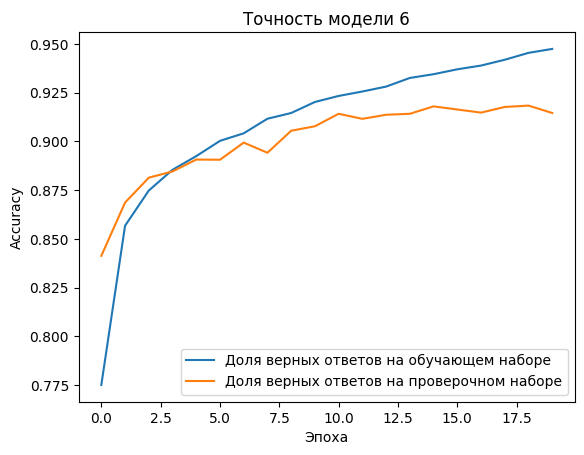

In [8]:
model6 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(),
    Dropout(0.3),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model6.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history6 = model6.fit(x_train.reshape(-1,28,28,1), y_train,
                      epochs=20, batch_size=128,
                      validation_data=(x_val.reshape(-1,28,28,1), y_val))

scores6 = model6.evaluate(x_test.reshape(-1,28,28,1), y_test, verbose=0)

plt.plot(history6.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history6.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.title("Точность модели 6")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 7 - Сверточная сеть с Batch Normalization и Dropout

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8321 - loss: 0.4704 - val_accuracy: 0.6247 - val_loss: 1.1002
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8862 - loss: 0.3090 - val_accuracy: 0.8881 - val_loss: 0.3102
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9009 - loss: 0.2688 - val_accuracy: 0.8839 - val_loss: 0.3143
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9093 - loss: 0.2424 - val_accuracy: 0.9014 - val_loss: 0.2670
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9174 - loss: 0.2210 - val_accuracy: 0.9088 - val_loss: 0.2562
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9239 - loss: 0.2028 - val_accuracy: 0.9028 - val_loss: 0.2902
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9289 - loss: 0.1877 - val_accuracy: 0.8984 - val_loss: 0.2854
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9334 - loss: 0.1757 - val_accuracy: 

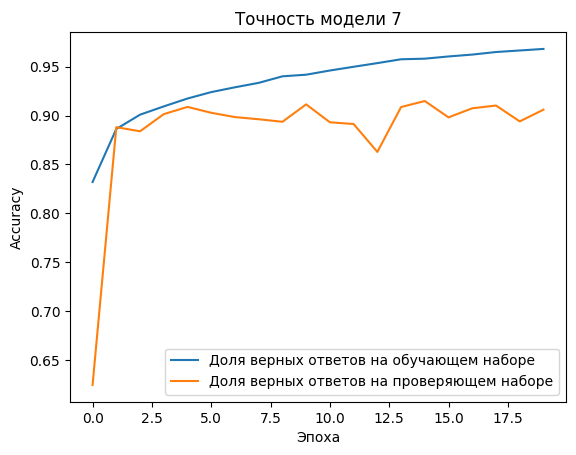

In [9]:
model7 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model7.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history7 = model7.fit(x_train.reshape(-1,28,28,1), y_train,
                      epochs=20, batch_size=128,
                      validation_data=(x_val.reshape(-1,28,28,1), y_val))

scores7 = model7.evaluate(x_test.reshape(-1,28,28,1), y_test, verbose=0)

plt.plot(history7.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history7.history['val_accuracy'], label='Доля верных ответов на проверяющем наборе')
plt.title("Точность модели 7")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 8 - Углубленная сверточная сеть с Global Average Pooling

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.4924 - loss: 1.3318 - val_accuracy: 0.6885 - val_loss: 0.8831
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6561 - loss: 0.9239 - val_accuracy: 0.7169 - val_loss: 0.7809
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6868 - loss: 0.8431 - val_accuracy: 0.7369 - val_loss: 0.7386
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7118 - loss: 0.7881 - val_accuracy: 0.7476 - val_loss: 0.6871
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7250 - loss: 0.7461 - val_accuracy: 0.7623 - val_loss: 0.6476
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7376 - loss: 0.7120 - val_accuracy: 0.7647 - val_loss: 0.6268
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7444 - loss: 0.6867 - val_accuracy: 0.7805 - val_loss: 0.5880
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7555 - loss: 0.6612 - val_accuracy: 0

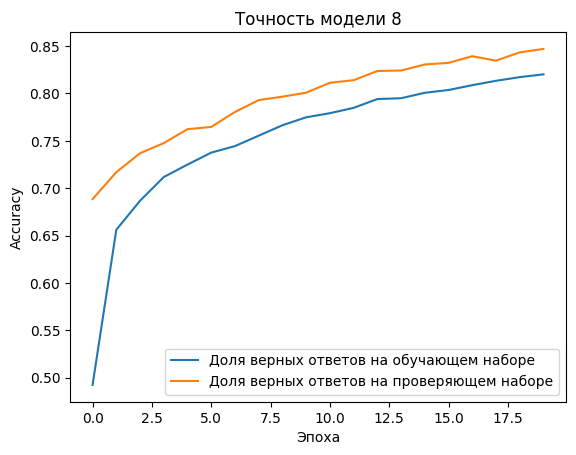

In [10]:
model8 = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(),
    Conv2D(128, (3,3), activation='relu'),
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model8.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history8 = model8.fit(x_train.reshape(-1,28,28,1), y_train,
                      epochs=20, batch_size=128,
                      validation_data=(x_val.reshape(-1,28,28,1), y_val))

scores8 = model8.evaluate(x_test.reshape(-1,28,28,1), y_test, verbose=0)

plt.plot(history8.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history8.history['val_accuracy'], label='Доля верных ответов на проверяющем наборе')
plt.title("Точность модели 8")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Модель 9 - Глубокая сверточная сеть с улучшенной архитектурой

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8213 - loss: 0.4878 - val_accuracy: 0.6494 - val_loss: 1.0317
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8815 - loss: 0.3232 - val_accuracy: 0.8879 - val_loss: 0.3030
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8972 - loss: 0.2799 - val_accuracy: 0.8830 - val_loss: 0.3222
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9053 - loss: 0.2562 - val_accuracy: 0.8917 - val_loss: 0.2953
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9146 - loss: 0.2311 - val_accuracy: 0.9054 - val_loss: 0.2654
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9190 - loss: 0.2166 - val_accuracy: 0.8839 - val_loss: 0.3331
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9243 - loss: 0.2036 - val_accuracy: 0.8936 - val_loss: 0.2843
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9287 - loss: 0.1882 - val_accuracy: 

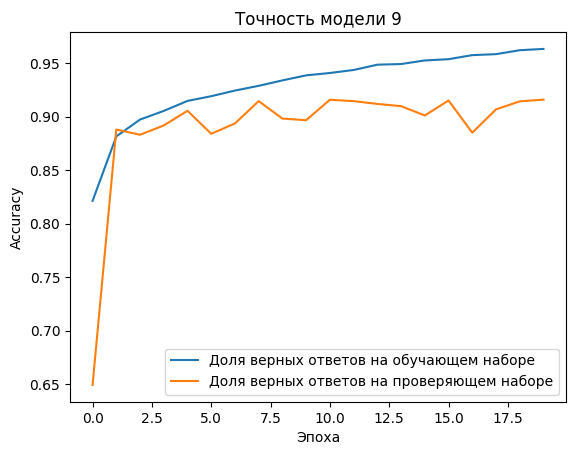

In [11]:
model9 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model9.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

history9 = model9.fit(x_train.reshape(-1,28,28,1), y_train,
                      epochs=20, batch_size=128,
                      validation_data=(x_val.reshape(-1,28,28,1), y_val))

scores9 = model9.evaluate(x_test.reshape(-1,28,28,1), y_test, verbose=0)

plt.plot(history9.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history9.history['val_accuracy'], label='Доля верных ответов на проверяющем наборе')
plt.title("Точность модели 9")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Таблица результатов

In [13]:
df = pd.DataFrame({
    "Модель": [f"Model {i}" for i in range(1,10)],
    "Validation Accuracy": [
        history1.history['val_accuracy'][-1],
        history2.history['val_accuracy'][-1],
        history3.history['val_accuracy'][-1],
        history4.history['val_accuracy'][-1],
        history5.history['val_accuracy'][-1],
        history6.history['val_accuracy'][-1],
        history7.history['val_accuracy'][-1],
        history8.history['val_accuracy'][-1],
        history9.history['val_accuracy'][-1]
    ],
    "Test Accuracy": [
        scores1[1], scores2[1], scores3[1], scores4[1],
        scores5[1], scores6[1], scores7[1], scores8[1], scores9[1]
    ]
})

df

,Модель,Validation Accuracy,Test Accuracy
0,Model 1,0.8913,0.8869
1,Model 2,0.8892,0.8845
2,Model 3,0.8773,0.8743
3,Model 4,0.8842,0.8854
4,Model 5,0.9129,0.9108
5,Model 6,0.9146,0.9075
6,Model 7,0.9060,0.9054
7,Model 8,0.8470,0.8458
8,Model 9,0.9158,0.9121
